In [1]:
#Importation of the neccessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
regulatory_data = pd.read_csv('regulatory_data.csv')
historical_energy_data = pd.read_csv('historical_energy_data.csv')
infrastructure_data = pd.read_csv('infrastructure_data.csv')
market_data = pd.read_csv('market_data.csv')   

In [3]:

# Define the correct date format that matches your data (DD/MM/YYYY)
date_format = "%d/%m/%Y"

# Convert the 'Date/Time' column to datetime using the correct format
historical_energy_data['Date/Time'] = pd.to_datetime(historical_energy_data['Date/Time'], format=date_format)

# If you want to CHANGE the format to YYYY-MM-DD after converting, you can add:
historical_energy_data['Date/Time'] = historical_energy_data['Date/Time'].dt.strftime('%Y-%m-%d')

In [4]:
# Define the correct date format that matches your data (DD/MM/YYYY)
date_format = "%d/%m/%Y"

# Convert the 'Date/Time' column to datetime using the correct format
infrastructure_data['Date/Time'] = pd.to_datetime(infrastructure_data['Date/Time'], format=date_format)

# If you want to CHANGE the format to YYYY-MM-DD after converting, you can add:
infrastructure_data['Date/Time'] = infrastructure_data['Date/Time'].dt.strftime('%Y-%m-%d')

In [5]:
date_format = '%Y-%m-%d'

market_data['Date/Time'] = pd.to_datetime(market_data['Date/Time'], format=date_format)

In [6]:
date_format = '%Y-%m-%d'

regulatory_data['Date/Time'] = pd.to_datetime(regulatory_data['Date/Time'], format=date_format)

In [7]:
#Specifically, we'll examine:
#Location/Region and Energy Source from historical_energy_data
#Infrastructure Status, Maintenance Activities, and Technology Limitations from infrastructure_data
#Competitor Data and Market Trends from market_data
#Regulatory Changes and Compliance Status from regulatory_data

#grouping all datasets at dataset
datasets ={"historical_energy_data":historical_energy_data,
           "infrastructure_data":infrastructure_data,
           "market_data":market_data,
           "regulatory_data":regulatory_data
}

#extracting unique values and their counts for categorical columns
categorical_columns={
    "historical_energy_data":["Location/Region","Energy Source"],
    "infrastructure_data":["Infrastructure Status","Maintenance Activities", "Technology Limitations"],
    "market_data":["Competitor Data", "Market Trends"],
    "regulatory_data":["Regulatory Changes","Compliance Status"]
}

categorical_values_counts ={}
for dataset, columns in categorical_columns.items():
    for column in columns:
         categorical_values_counts[(dataset, column)] = datasets[dataset][column].value_counts()

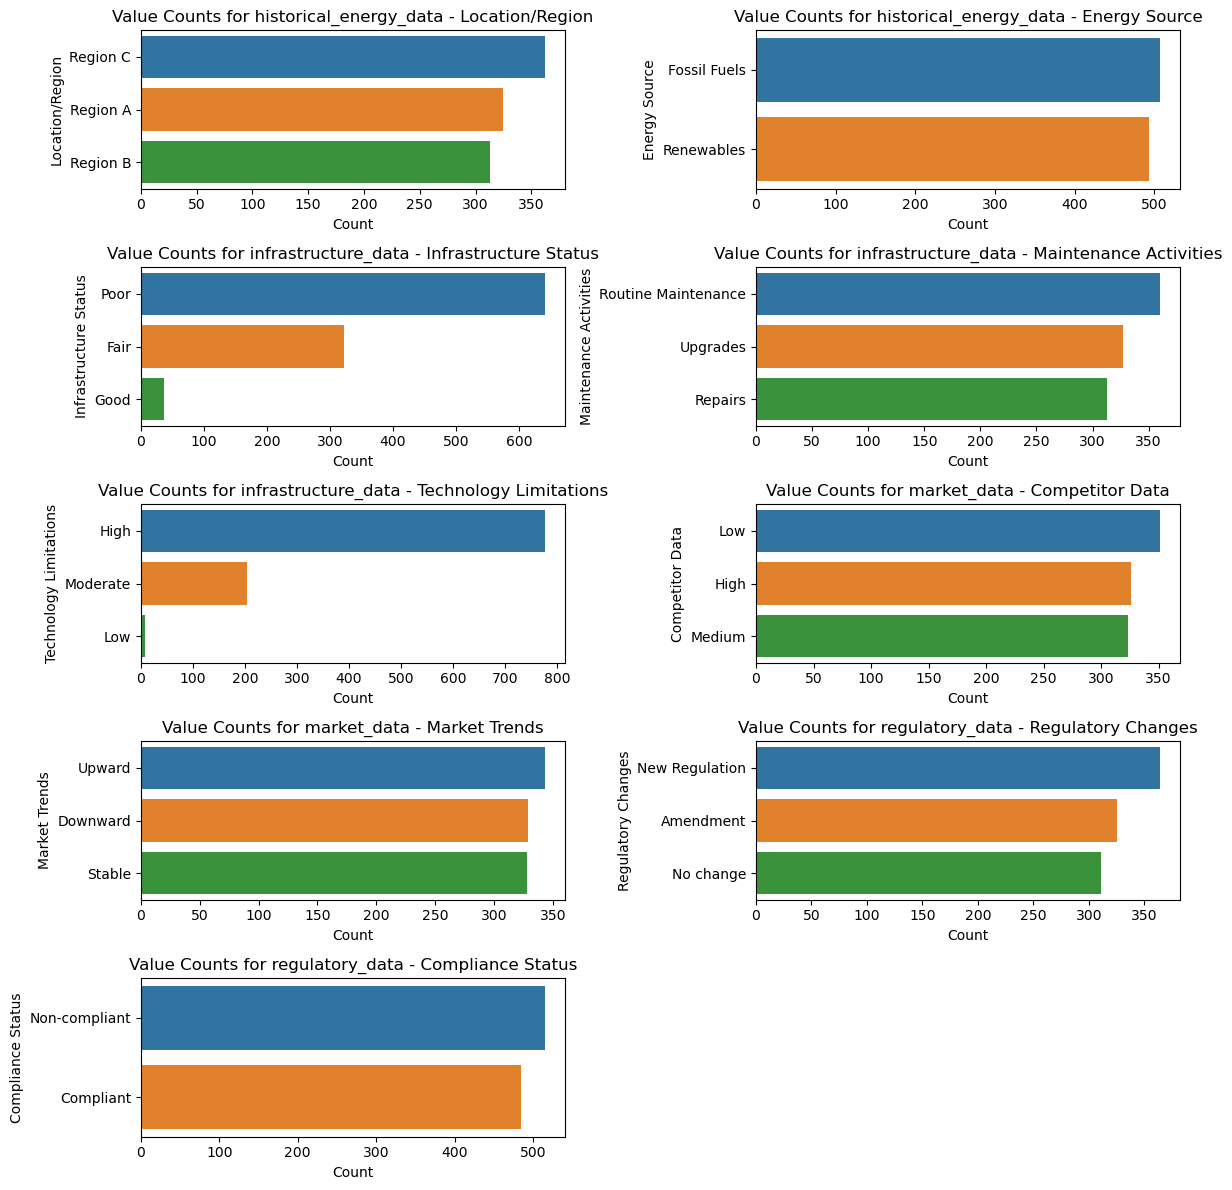

In [8]:
#visualizing
#calculate the number of rows and columns for the subplots
num_rows = (len(categorical_values_counts) +1) // 2
num_cols = 2

#create a grid of the subplots
fig, axes = plt.subplots(num_rows, num_cols, figsize= (12, 12))

#flatten the axes array for easier indexing
axes = axes.flatten()

#iterate through categorical columns and plots them in subplots
for i, ((dataset, column), counts) in enumerate(categorical_values_counts.items()):
   ax= axes[i]
   sns.barplot(x=counts.values, y= counts.index, ax=ax)
   ax.set_title(f"Value Counts for {dataset} - {column}")
   ax.set_xlabel("Count")
   ax.set_ylabel(column)

#hide any remaining empty subplolts
for i in range(len(categorical_values_counts), num_rows * num_cols):
    fig.delaxes(axes[i])
#adjust
plt.tight_layout()

plt.show()

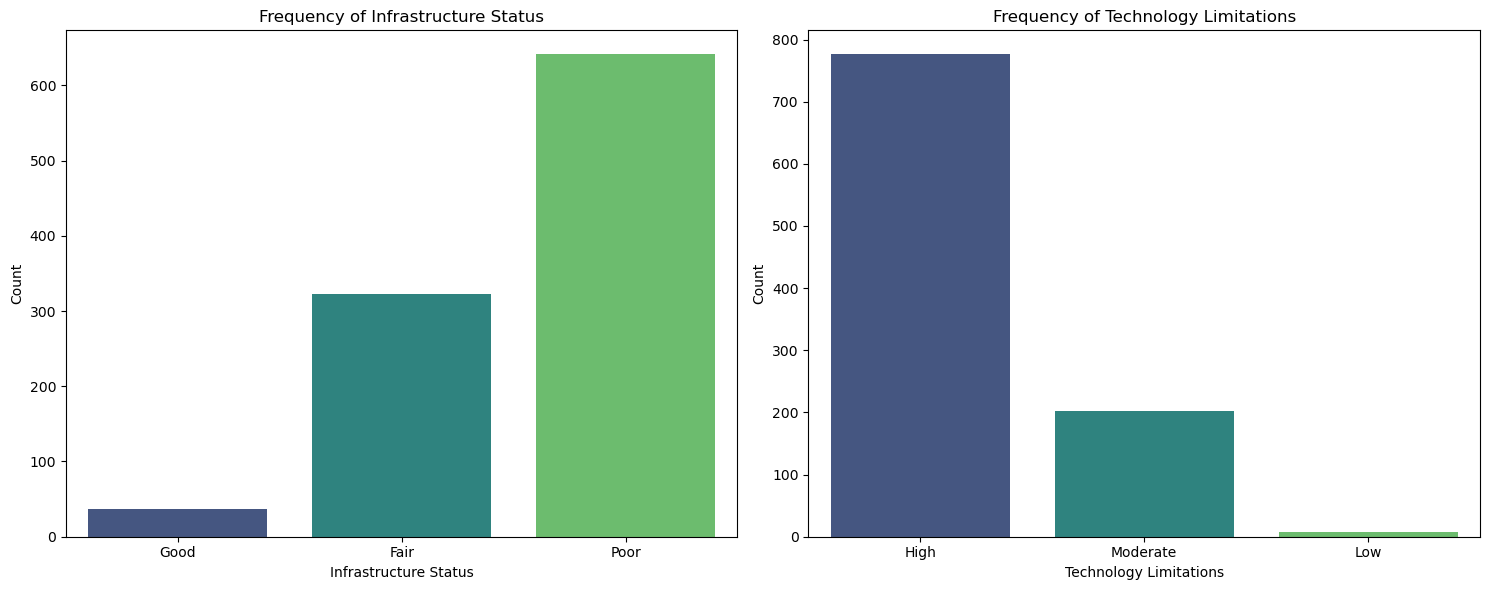

In [12]:
# Setting up the figure and axes
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

#Plotting the frequency of Infrastructure Status
sns.countplot(data=infrastructure_data, x='Infrastructure Status', ax=axes[0], order=['Good', 'Fair', 'Poor'], palette='viridis')
axes[0].set_title('Frequency of Infrastructure Status')  
axes[0].set_xlabel('Infrastructure Status')  
axes[0].set_ylabel('Count')  

sns.countplot(data=infrastructure_data, x='Technology Limitations', ax=axes[1], palette='viridis')
axes[1].set_title('Frequency of Technology Limitations')  
axes[1].set_xlabel('Technology Limitations') 
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

In [13]:
# Create binary indicator for poor infrastructure
infrastructure_data['Poor_Infrastructure'] = infrastructure_data['Infrastructure Status'].apply(lambda x: 1 if x == 'Poor' else 0)

# Create binary indicator for high tech limitations
infrastructure_data['High_Tech_Limitations'] = infrastructure_data['Technology Limitations'].apply(lambda x: 1 if x == 'Poor' else 0)

# Create combined column - using addition or logical OR operation
infrastructure_data['Combined'] = infrastructure_data['Poor_Infrastructure'] + infrastructure_data['High_Tech_Limitations']

# Merge the datasets
merged_data = pd.merge(historical_energy_data, infrastructure_data, on="Date/Time", how="inner")

# Calculate correlation
correlation_coefficient = merged_data['Energy Production (kWh)'].corr(merged_data['Combined'])
print(f"Correlation coefficient: {correlation_coefficient}")

Correlation coefficient: 0.045540018042463014


/opt/conda/envs/anaconda-ai-2024.04-py310/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


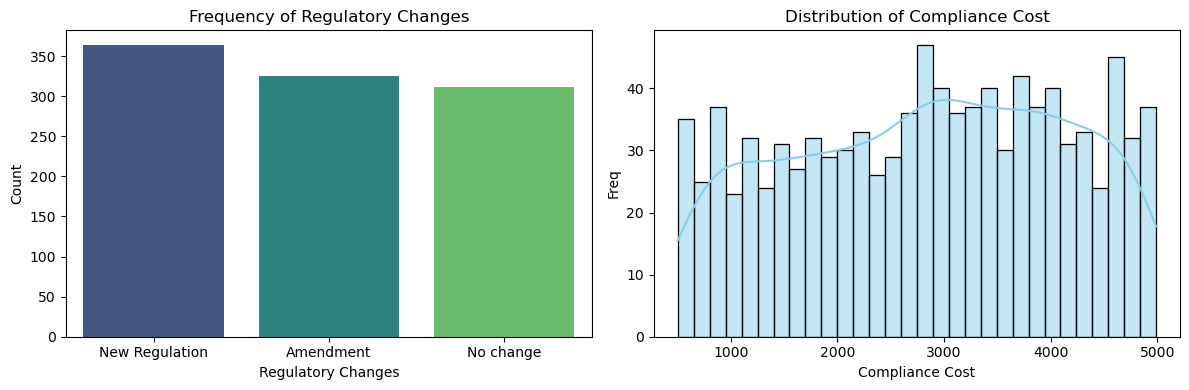

In [14]:
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(12, 4))

# Fixed the order of arguments - 'x' parameter should be a keyword argument
sns.countplot(x='Regulatory Changes', data=regulatory_data, ax=ax1, palette='viridis')
ax1.set_title('Frequency of Regulatory Changes')
ax1.set_xlabel('Regulatory Changes')
ax1.set_ylabel('Count')

sns.histplot(data=regulatory_data, x='Compliance Costs', ax=ax2, bins=30, kde=True, color='skyblue')
ax2.set_title('Distribution of Compliance Cost')
ax2.set_xlabel('Compliance Cost')
ax2.set_ylabel('Freq')

plt.tight_layout()
plt.show()

/opt/conda/envs/anaconda-ai-2024.04-py310/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/envs/anaconda-ai-2024.04-py310/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


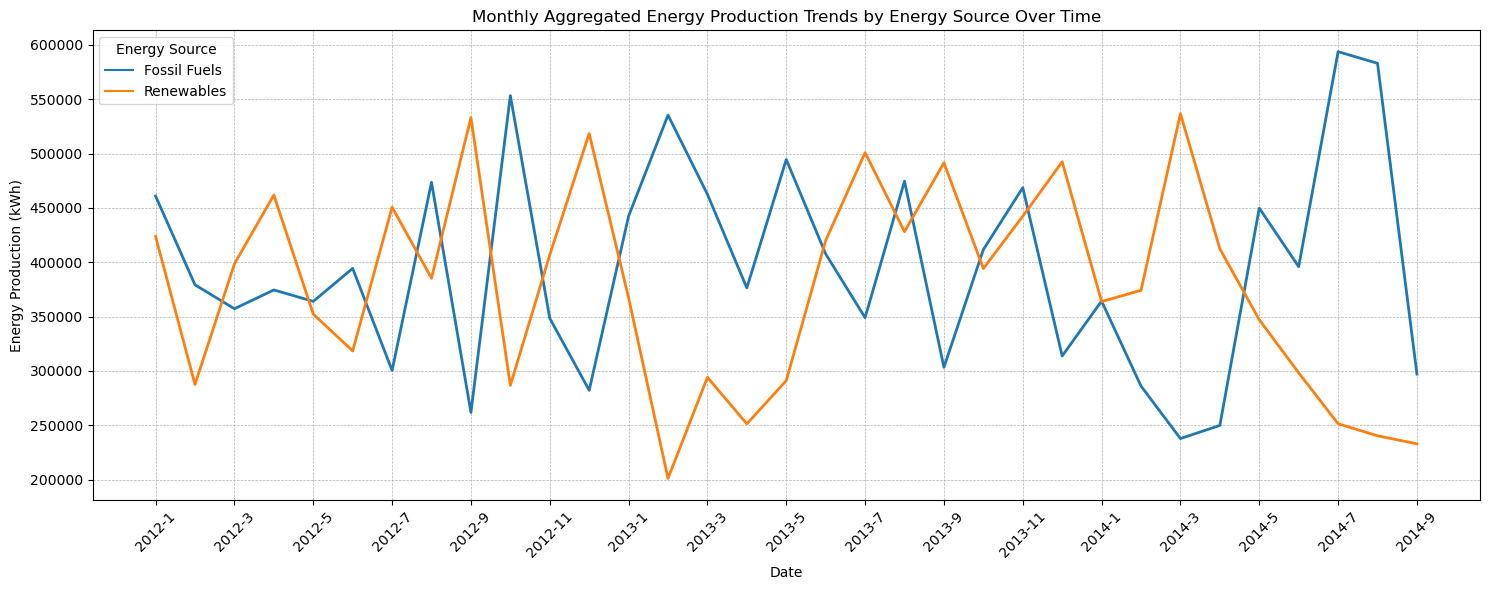

In [31]:
# First, make sure Year and Month are extracted correctly
historical_energy_data['Year'] = historical_energy_data['Date/Time'].dt.year
historical_energy_data['Month'] = historical_energy_data['Date/Time'].dt.month

# Specify which column to sum in the groupby operation
# This avoids trying to sum the datetime column
monthly_aggregated_data = historical_energy_data.groupby(['Year', 'Month', 'Energy Source'])['Energy Production (kWh)'].sum().reset_index()

monthly_aggregated_data['Year-Month'] = monthly_aggregated_data['Year'].astype(str) + '-' + monthly_aggregated_data['Month'].astype(str)
plt.figure(figsize=(15, 6))

# Changed 'Revenue' to 'Energy Production (kWh)' to match the column name in your data
sns.lineplot(data=monthly_aggregated_data, x='Year-Month', y='Energy Production (kWh)', hue='Energy Source', linewidth=2)
plt.title('Monthly Aggregated Energy Production Trends by Energy Source Over Time') 
                                                                                                                                                                           
plt.xlabel('Date') 
plt.ylabel('Energy Production (kWh)') 
plt.legend(title='Energy Source') 

plt.grid(True, which='both', linestyle='--', linewidth=0.5)
labels = monthly_aggregated_data['Year-Month'].tolist()
n = 4 
plt.xticks(labels[::n], rotation=45)  # Changed rotation for better readability
plt.tight_layout()  # Added to prevent label cutoff
plt.show()

/opt/conda/envs/anaconda-ai-2024.04-py310/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/envs/anaconda-ai-2024.04-py310/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/envs/anaconda-ai-2024.04-py310/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/envs/anaconda-ai-2024.04-py310/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_in

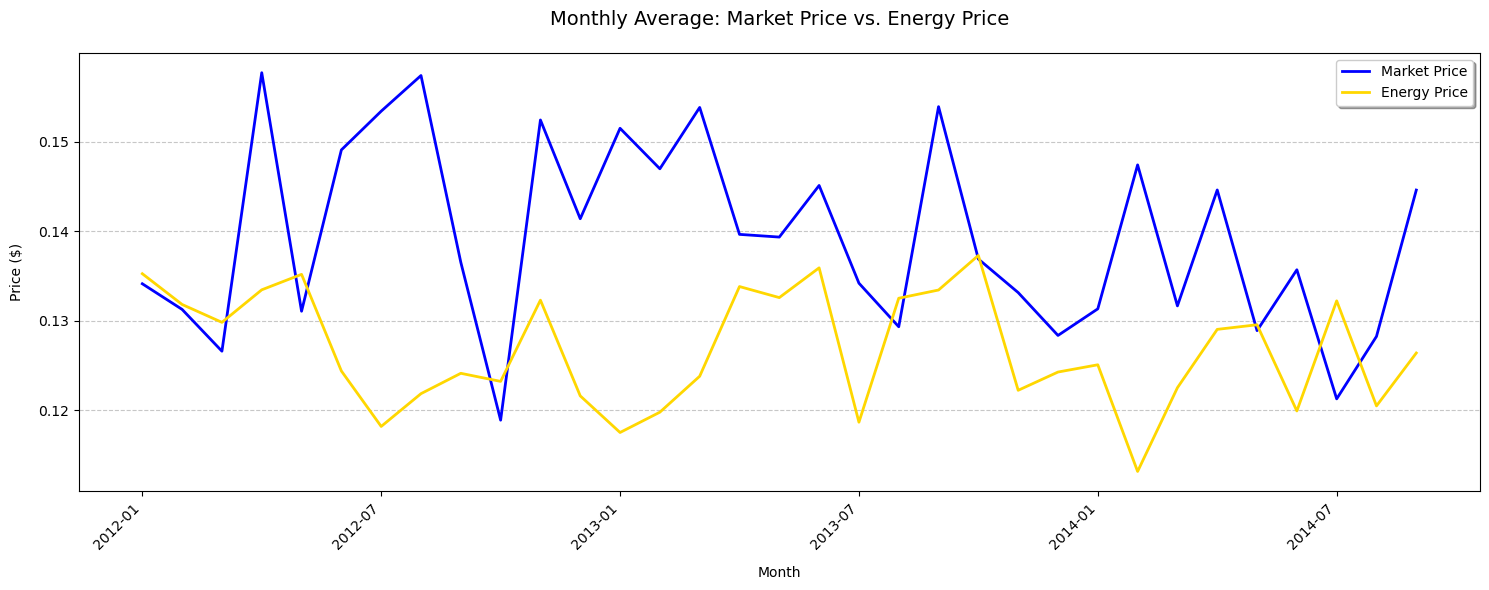

In [14]:

# Convert both Date/Time columns to datetime if they aren't already
historical_energy_data['Date/Time'] = pd.to_datetime(historical_energy_data['Date/Time'])
market_data['Date/Time'] = pd.to_datetime(market_data['Date/Time'])

# Now merge will work
merged_data = pd.merge(
    historical_energy_data,
    market_data,
    on="Date/Time",
    how="inner"
)


merged_data['Year-Month'] = merged_data['Date/Time'].dt.strftime('%Y-%m')
monthly_merged_data = merged_data.groupby('Year-Month', as_index=False).agg({
    'Market Price': 'mean',
    'Energy Price': 'mean'
})


# Plotting
plt.figure(figsize=(15, 6))

# Plot Market Price (blue)
sns.lineplot(
    data=monthly_merged_data,
    x='Year-Month',
    y='Market Price',
    label='Market Price',
    color='blue',
    linewidth=2
)

# Plot Energy Price (yellow)
sns.lineplot(
    data=monthly_merged_data,
    x='Year-Month',
    y='Energy Price',
    label='Energy Price',
    color='gold',  # More visible than plain yellow
    linewidth=2
)

# Formatting
plt.title('Monthly Average: Market Price vs. Energy Price', pad=20, fontsize=14)
plt.xlabel('Month', labelpad=10)
plt.ylabel('Price ($)', labelpad=10)
plt.legend(framealpha=1, shadow=True)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# X-axis labels (show every 6 months)
n = 6  
ticks = range(0, len(monthly_merged_data), n)
labels = monthly_merged_data['Year-Month'].iloc[ticks]
plt.xticks(ticks, labels, rotation=45, ha='right')

plt.tight_layout()
plt.show()

/opt/conda/envs/anaconda-ai-2024.04-py310/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/envs/anaconda-ai-2024.04-py310/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


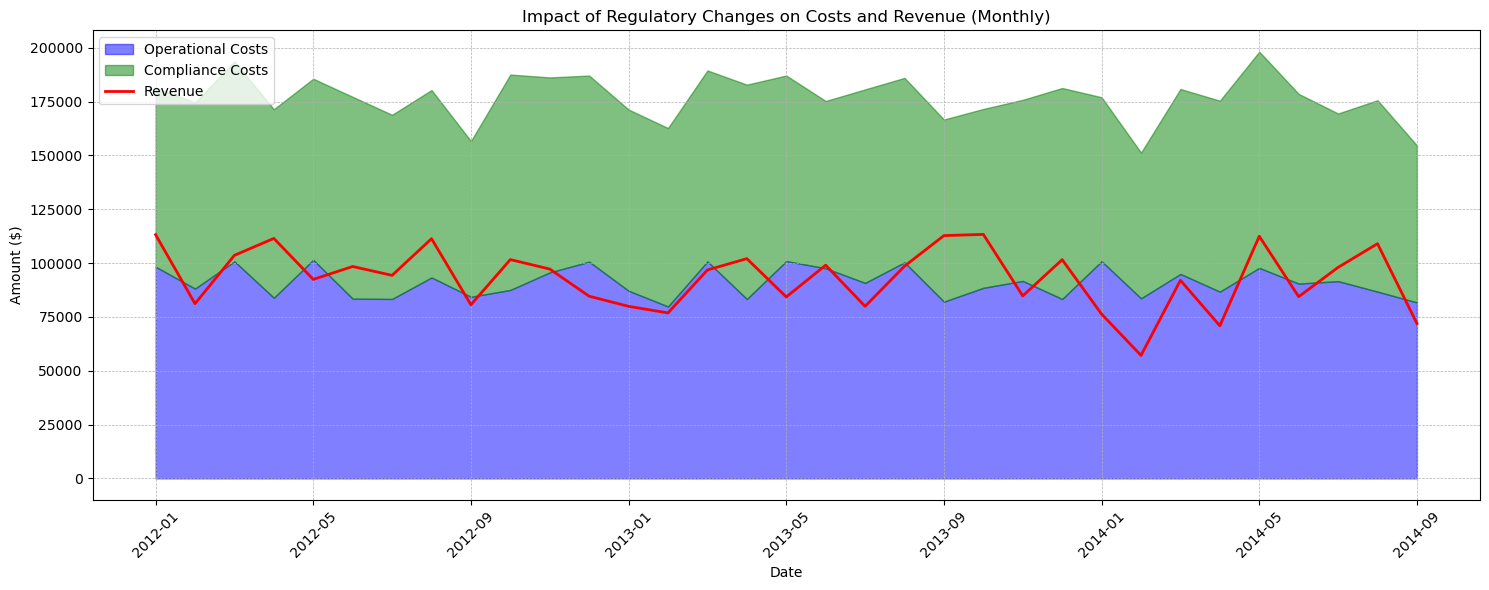

In [26]:
# First line seems incomplete, assuming it's part of datetime conversion
# regulatory_data['Date/Time'] = pd.to_datetime(regulatory_data['Date/Time'])

# Now merge the datasets with consistent datetime types
merged_regulatory_data = pd.merge(historical_energy_data, regulatory_data, on="Date/Time", how="inner")

# Extract year and month
merged_regulatory_data['Year'] = merged_regulatory_data['Date/Time'].dt.year
merged_regulatory_data['Month'] = merged_regulatory_data['Date/Time'].dt.month

# Select only numeric columns for aggregation (excluding Year and Month from numeric_cols)
numeric_cols = merged_regulatory_data.select_dtypes(include=['number']).columns.tolist()

# Create monthly_aggregated first - this was missing
# Assuming we want to group by Year and Month and aggregate numeric columns
monthly_aggregated = merged_regulatory_data.groupby(['Year', 'Month'])[numeric_cols].sum()

monthly_aggregated = monthly_aggregated.rename(columns={
    'Year': 'Year_data',
    'Month': 'Month_data'
})
monthly_aggregated_data = monthly_aggregated.reset_index()

# Create Year-Month string for plotting (with zero-padded months)
monthly_aggregated_data['Year-Month'] = (
    monthly_aggregated_data['Year'].astype(str) + '-' + 
    monthly_aggregated_data['Month'].astype(str).str.zfill(2)
)

# Plotting
plt.figure(figsize=(15, 6))

plt.fill_between(monthly_aggregated_data['Year-Month'], 
                monthly_aggregated_data['Operational Costs'], 
                color='blue', label='Operational Costs', alpha=0.5)

plt.fill_between(monthly_aggregated_data['Year-Month'], 
                monthly_aggregated_data['Operational Costs'], 
                monthly_aggregated_data['Operational Costs'] + monthly_aggregated_data['Compliance Costs'],
                color='green', alpha=0.5, label='Compliance Costs')

sns.lineplot(data=monthly_aggregated_data, x='Year-Month', y='Revenue', 
            label='Revenue', color='red', linewidth=2)
                
plt.title('Impact of Regulatory Changes on Costs and Revenue (Monthly)')
plt.xlabel('Date')
plt.ylabel('Amount ($)')
plt.legend(loc='upper left')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)

# Show every nth label to avoid crowding
n = 4
labels = monthly_aggregated_data['Year-Month'].tolist()
plt.xticks(labels[::n], rotation=45)
plt.tight_layout()
plt.show()

# General Insights: 

1. **Dynamic Energy Landscape**: Energix Enterprise experiences marked variance in energy production, consumption and demand patterns. There are distinct  periods where the demand overshadows production highlighting potential areas of concern in market stability and supply consistency.

2. **Pricing Volatility**: Energix's energy pricing exhibits variability in alignment with broader market price trends. Notably, the energy price remains uncorrelated with energy demand presenting potential challenges in sales predictability and revenue forecasting

3. **Infrastructure & Technology Concerns**: A significant portion of the company's infrastructure is categorised as 'poor'. Coupled with pronounced technology Limitations. there's a compelling case of comprehensive infrastructure rejuvenation. Preliminary analysis suggests that periods of 'Poor' infrastructure status and 'High' technology constraints may correlate with diminished energy production

4. **Regulatory & Financial Implications**: Energix is continually navigating a changing regulatory landscape, with new mandates and modifications to existing ones. The finanacial ramifications especially in terms of compliance costs and operational expenditures are substantial. A juxtaposition of these costs with the firm's current revenue trajectory indicates a pressing profitability challenge.

5. **Emergence of Renewables**: The energy market is witnessing a paradigm shift with renewables gaining prominence . Data trends suggest instances where renewable energy production has eclipsed that of fossil fuels. For Energix, this underscores the dual challenges of evolving competition and potential erosion of market share
 

# Resillience Planning and Recommendations

1. **Balanced Energy Portfolio**: Energix Enterprise should consider diversifying its energy production portfolio to mitigate the risks associated with fluctuations in demand and production. A balanced mix of renewable and non-renewable sources can help stabilise the energy supply and meet demand more consistently.

2. **Dynamic Pricing Model**: Given that energy price doesn't correlate with energy demand . Energix should consider implementing a dynamic pricing model. This model can adjust prices based on demand, production, costs and other market factors. Such a model can help in improving sales during high-demand periods and maintaining profitability during low-demand times.

3. **Infrastructure Revamp**: With most of the Company's infrastructure in 'Poor' status and high technology Limitations. Energix should prioritise investments in infrastructure upgrades. Modernizing infrastructure can lead to increased production efficiency, reduced downtimes and potentially higher energy output.

4. **Regulatory Compliance Fund and Operational Cost**: Given the periodic introduction of new regulations and the associated compliance costs, Energix should establish a dedicated fund or reserve to address these unforeseen expenses. This approach can help in budgetting  and ensuring that the costs dont significantly impact the company's bottom line.

5. **Enhance Renewables**: The trend towards renewable energy is evident. Energix should consider increasing its investment in renewable energy technologies and infrastructure. This not only aligns with global sustainability goals  but also positions the company to better  compete in an evolving energy market.

6. **Cost Management and Revenue Generations**: Considering the operational and compliance costs are impacting profitability. Energix should undertake a thorough review of its operations to identify cost-saving opportunities. Additionally, exploring alternative revenue streams such as energy storage solutions or consultancy services. This can further bolster the companies financial position.

7. **Stakeholder Engagement**: Engage with regulatory bodies proactively to stay ahead of potential regulatory changes. This proactive approach can help in better preparation and can also influence regulations in a manner favourable to Energix

8. **Market Research & Consumer Insights**: Conduct regular market research to understand consumer preferences especially concerning renewable energy. This can guide Energix's strategy in terms of energy source diversification and pricing.

Inconclusing, while Energix faces challenges in terms of fluctuating demand, aging infrastructure and increasing competition from renewables, there are clear  strategic paths available. By modernizing infrastructure diversifying energy sources and adopting a dynamic pricing model, Energix can position itself for a sustained growth and profitability in the future energy market.



